# Notebook 04 — Evaluación y Explicabilidad (SHAP)

**Proyecto:** Predicción de Riesgo de Incumplimiento Crediticio  
**Inputs:** `models/random_forest_ganador.pkl` · `models/model_metadata.json` · `data/processed/data_test.csv`  
**Output:** Gráficos de evaluación profunda + gráficos SHAP

Este notebook carga el modelo ganador ya entrenado y lo evalúa en profundidad: análisis de errores, curvas de calibración y explicabilidad con SHAP a nivel global y local.

---

## Índice

1. Carga del modelo ganador y datos del set
2. Evaluación profunda — análisis de errores
3. Curva de calibración
4. SHAP — configuración
5. SHAP global — importancia de variables
6. SHAP global — efectos de cada variable
7. SHAP local — explicación por cliente individual
8. Conclusiones

---
## 1. Carga del modelo ganador y datos del set

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import json
import shap
import warnings

from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    precision_recall_curve,
    recall_score, precision_score, f1_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
shap.initjs()

TARGET = 'SeriousDlqin2yrs'

# Cargar metadata del modelo ganador
with open('../models/model_metadata.json', 'r') as f:
    metadata = json.load(f)

MODELO_NOMBRE = metadata['modelo']
MODELO_ARCHIVO = metadata['archivo']
UMBRAL = metadata['umbral_optimo']
FEATURES = metadata['features']

print(f'Modelo ganador: {MODELO_NOMBRE}')
print(f'Umbral óptimo: {UMBRAL}')
print(f'Features: {FEATURES}')

# Cargar modelo
modelo = joblib.load(f'../models/{MODELO_ARCHIVO}')

# Cargar test set
test = pd.read_csv('../data/processed/data_test.csv')
X_test = test[FEATURES]
y_test = test[TARGET]

# Predicciones con umbral óptimo
y_prob = modelo.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= UMBRAL).astype(int)

print(f'\nTest set: {X_test.shape[0]:,} filas')

c:\Users\Usuario\AppData\Local\Python\pythoncore-3.13-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Modelo ganador: Random Forest
Umbral óptimo: 0.49
Features: ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse', 'age', 'NumberOfOpenCreditLinesAndLoans', 'MonthlyIncome', 'DebtRatio', 'NumberRealEstateLoansOrLines', 'NumberOfDependents']

Test set: 30,000 filas


---
## 2. Evaluación profunda — análisis de errores

Más allá de las métricas generales, analizamos **dónde** se equivoca el modelo: el perfil de los falsos negativos (morosos que el modelo no detectó) es la información más valiosa para el negocio.

In [3]:
# Métricas finales
auc = roc_auc_score(y_test, y_prob)
recall = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'=== Métricas finales — {MODELO_NOMBRE} (umbral={UMBRAL}) ===')
print(f' AUC-ROC: {auc:.4f}')
print(f' Recall: {recall:.4f} ← prioridad')
print(f' Precisión: {prec:.4f}')
print(f' F1-Score: {f1:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No moroso', 'Moroso']))


=== Métricas finales — Random Forest (umbral=0.49) ===
 AUC-ROC: 0.8513
 Recall: 0.4539 ← prioridad
 Precisión: 0.3722
 F1-Score: 0.4090

              precision    recall  f1-score   support

   No moroso       0.96      0.95      0.95     27995
      Moroso       0.37      0.45      0.41      2005

    accuracy                           0.91     30000
   macro avg       0.67      0.70      0.68     30000
weighted avg       0.92      0.91      0.92     30000



=== Desglose de la matriz de confusión ===
 Verdaderos Negativos (TN): 26,460 — no morosos correctamente identificados
 Falsos Positivos (FP): 1,535 — clientes buenos marcados como morosos
 Falsos Negativos (FN): 1,095 — morosos que el modelo NO detectó ← crítico
 Verdaderos Positivos (TP): 910 — morosos correctamente identificados

 Tasa de detección de morosos (Recall): 45.39%
 Morosos no detectados: 54.61%


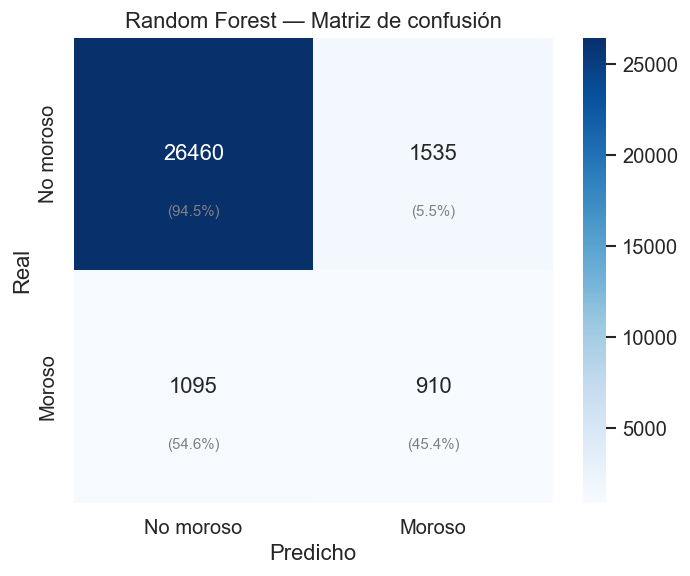

In [4]:
# Matriz de confusión detallada
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print('=== Desglose de la matriz de confusión ===')
print(f' Verdaderos Negativos (TN): {tn:,} — no morosos correctamente identificados')
print(f' Falsos Positivos (FP): {fp:,} — clientes buenos marcados como morosos')
print(f' Falsos Negativos (FN): {fn:,} — morosos que el modelo NO detectó ← crítico')
print(f' Verdaderos Positivos (TP): {tp:,} — morosos correctamente identificados')
print()
print(f' Tasa de detección de morosos (Recall): {tp/(tp+fn):.2%}')
print(f' Morosos no detectados: {fn/(tp+fn):.2%}')

fig, ax = plt.subplots(figsize=(6, 5))
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No moroso', 'Moroso'],
            yticklabels=['No moroso', 'Moroso'])
# Añadir porcentajes
for i in range(2):
    for j in range(2):
        ax.text(j+0.5, i+0.75, f'({cm_pct[i,j]:.1%})',
                ha='center', va='center', fontsize=9, color='gray')
ax.set_title(f'{MODELO_NOMBRE} — Matriz de confusión')
ax.set_ylabel('Real')
ax.set_xlabel('Predicho')
plt.tight_layout()
plt.show()

In [6]:
# Perfil de los falsos negativos vs verdaderos positivos
# Pregunta: ¿En qué se diferencian los morosos detectados de los no detectados?
df_morosos = X_test.copy()
df_morosos['real'] = y_test.values
df_morosos['predicho'] = y_pred
df_morosos['prob'] = y_prob

fn_mask = (df_morosos['real'] == 1) & (df_morosos['predicho'] == 0) # falsos negativos
tp_mask = (df_morosos['real'] == 1) & (df_morosos['predicho'] == 1) # verdaderos positivos

df_fn = df_morosos[fn_mask][FEATURES]
df_tp = df_morosos[tp_mask][FEATURES]

comparacion = pd.DataFrame({
    'Morosos NO detectados (FN)': df_fn.mean(),
    'Morosos detectados (TP)': df_tp.mean()
}).round(3)

print(f'=== Perfil promedio: morosos detectados vs no detectados ===')
print(f'Falsos negativos: {fn_mask.sum():,} clientes')
print(f'Verdaderos positivos: {tp_mask.sum():,} clientes')
print()
print(comparacion.to_string())

=== Perfil promedio: morosos detectados vs no detectados ===
Falsos negativos: 1,095 clientes
Verdaderos positivos: 910 clientes

                                      Morosos NO detectados (FN)  Morosos detectados (TP)
RevolvingUtilizationOfUnsecuredLines                       0.562                    0.895
NumberOfTimes90DaysLate                                    0.058                    1.370
NumberOfTime30-59DaysPastDueNotWorse                       0.417                    1.666
age                                                       46.822                   43.421
NumberOfOpenCreditLinesAndLoans                            9.408                    6.455
MonthlyIncome                                           5707.520                 5009.502
DebtRatio                                                296.470                  253.736
NumberRealEstateLoansOrLines                               1.207                    0.746
NumberOfDependents                                         0

---
## 3. Curva de calibración

La calibración mide si las probabilidades del modelo son realistas. Si el modelo dice "30% de probabilidad de default", en la realidad deberíamos ver que aproximadamente el 30% de esos clientes efectivamente son morosos.

Un modelo bien calibrado es especialmente importante para fijar límites de crédito proporcionales al riesgo.

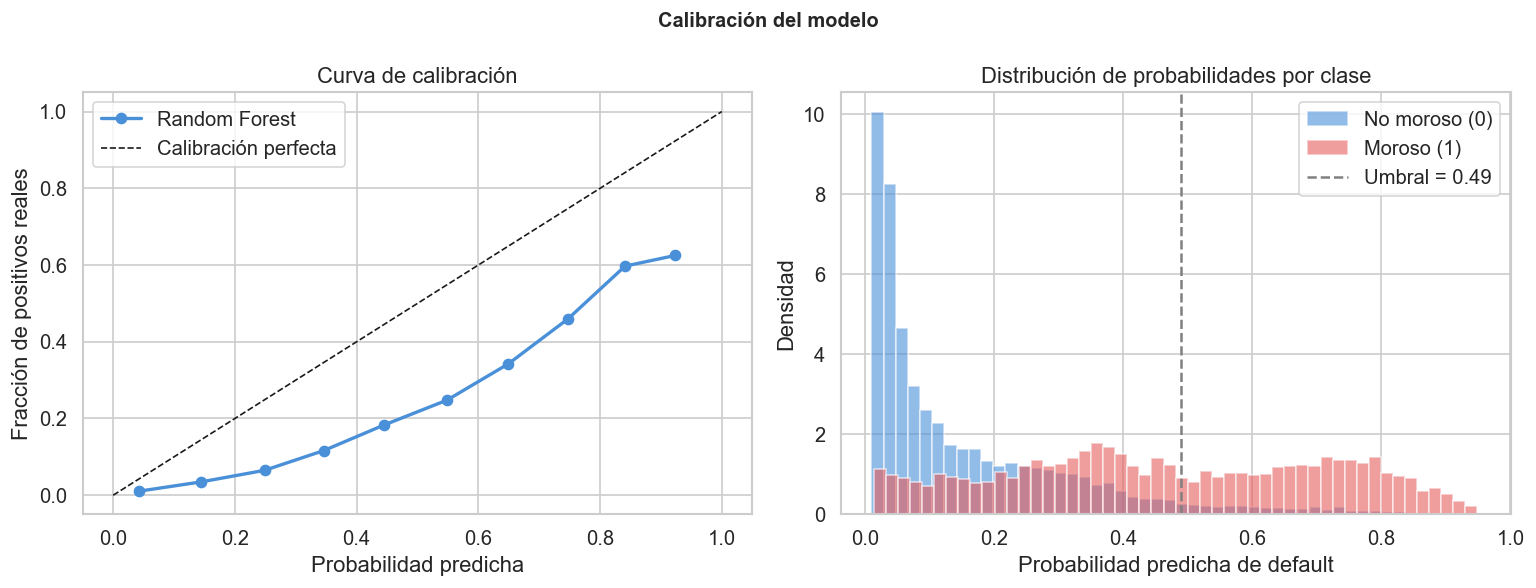

In [7]:
prob_real, prob_predicha = calibration_curve(y_test, y_prob, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Curva de calibración
axes[0].plot(prob_predicha, prob_real, 'o-', color='#4A90D9', lw=2, label=MODELO_NOMBRE)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Calibración perfecta')
axes[0].set_xlabel('Probabilidad predicha')
axes[0].set_ylabel('Fracción de positivos reales')
axes[0].set_title('Curva de calibración')
axes[0].legend()

# Distribución de probabilidades predichas por clase
axes[1].hist(y_prob[y_test == 0], bins=50, alpha=0.6, color='#4A90D9', label='No moroso (0)', density=True)
axes[1].hist(y_prob[y_test == 1], bins=50, alpha=0.6, color='#E55C5C', label='Moroso (1)', density=True)
axes[1].axvline(UMBRAL, color='gray', lw=1.5, ls='--', label=f'Umbral = {UMBRAL}')
axes[1].set_xlabel('Probabilidad predicha de default')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de probabilidades por clase')
axes[1].legend()

plt.suptitle('Calibración del modelo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. SHAP — configuración

**SHAP** (SHapley Additive exPlanations) explica las predicciones del modelo calculando la contribución individual de cada variable a cada predicción.

- **Valor SHAP positivo** → esa variable empuja la predicción hacia moroso
- **Valor SHAP negativo** → esa variable empuja la predicción hacia no moroso
- **Magnitud** → cuánto impacto tiene esa variable en la predicción

Usamos `TreeExplainer` — optimizado para modelos basados en árboles (Random Forest, XGBoost).

**Justificación técnica (Explicabilidad SHAP en modelo ganador):** El cálculo de contribuciones marginales de Shapley es computacionalmente intensivo. Limitar el análisis SHAP al modelo ganador optimiza recursos y centra los esfuerzos de explicabilidad en el algoritmo que efectivamente se implementará en producción.

In [12]:
print('Calculando valores SHAP — esto puede tardar unos minutos...')

explainer = shap.TreeExplainer(modelo)

np.random.seed(42)
idx_muestra = np.random.choice(len(X_test), size=1000, replace=False)
X_muestra   = X_test.iloc[idx_muestra].reset_index(drop=True)

shap_values = explainer.shap_values(X_muestra)

# TreeExplainer sobre Random Forest puede devolver:
#   - lista [clase_0, clase_1]  → tomamos clase 1
#   - array 3D (muestras, features, clases) → tomamos [:, :, 1]
#   - array 2D (muestras, features)         → ya está listo
if isinstance(shap_values, list):
    sv = shap_values[1]
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

# Aseguramos 2D para todos los cálculos posteriores
assert sv.ndim == 2, f'Shape inesperado: {sv.ndim}D'

print(f'Valores SHAP calculados para {len(X_muestra):,} clientes.')
print(f'Shape: {sv.shape}  ({sv.shape[0]} clientes × {sv.shape[1]} features)')

Calculando valores SHAP — esto puede tardar unos minutos...
Valores SHAP calculados para 1,000 clientes.
Shape: (1000, 9)  (1000 clientes × 9 features)


---
## 5. SHAP global — importancia de variables

El **mean |SHAP|** por variable mide el impacto promedio de cada feature en todas las predicciones. Es la versión de "feature importance" más robusta y confiable.

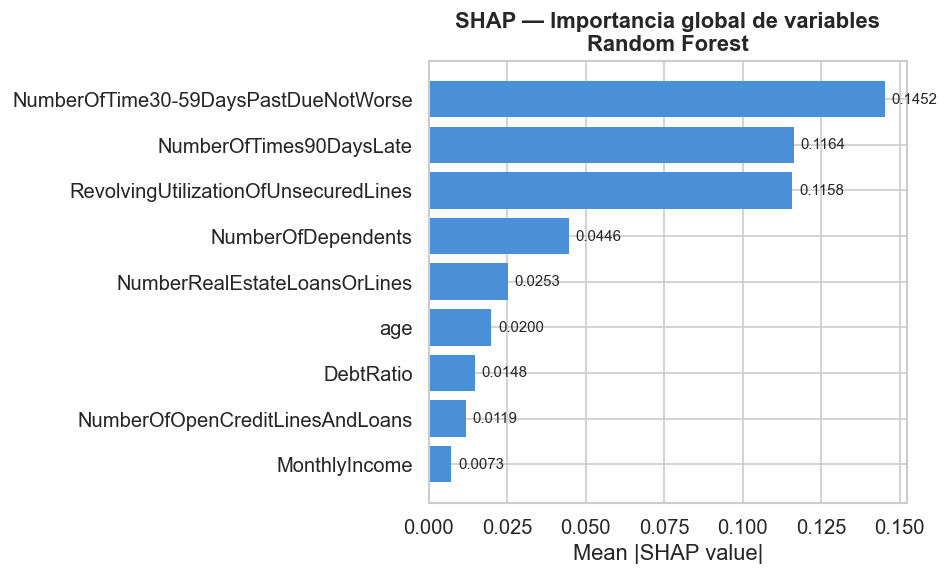

=== Ranking de importancia (SHAP) ===
                             Feature  SHAP medio
NumberOfTime30-59DaysPastDueNotWorse    0.145211
             NumberOfTimes90DaysLate    0.116430
RevolvingUtilizationOfUnsecuredLines    0.115843
                  NumberOfDependents    0.044597
        NumberRealEstateLoansOrLines    0.025336
                                 age    0.019981
                           DebtRatio    0.014753
     NumberOfOpenCreditLinesAndLoans    0.011872
                       MonthlyIncome    0.007293


In [13]:
# Importancia global: promedio del valor absoluto de SHAP por feature
importancia_shap = pd.DataFrame({
    'Feature'    : FEATURES,
    'SHAP medio' : np.abs(sv).mean(axis=0)
}).sort_values('SHAP medio', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(importancia_shap['Feature'], importancia_shap['SHAP medio'], color='#4A90D9', edgecolor='none')
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=9)
ax.set_title(f'SHAP — Importancia global de variables\n{MODELO_NOMBRE}', fontweight='bold')
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.show()

print('=== Ranking de importancia (SHAP) ===')
print(importancia_shap.sort_values('SHAP medio', ascending=False).to_string(index=False))

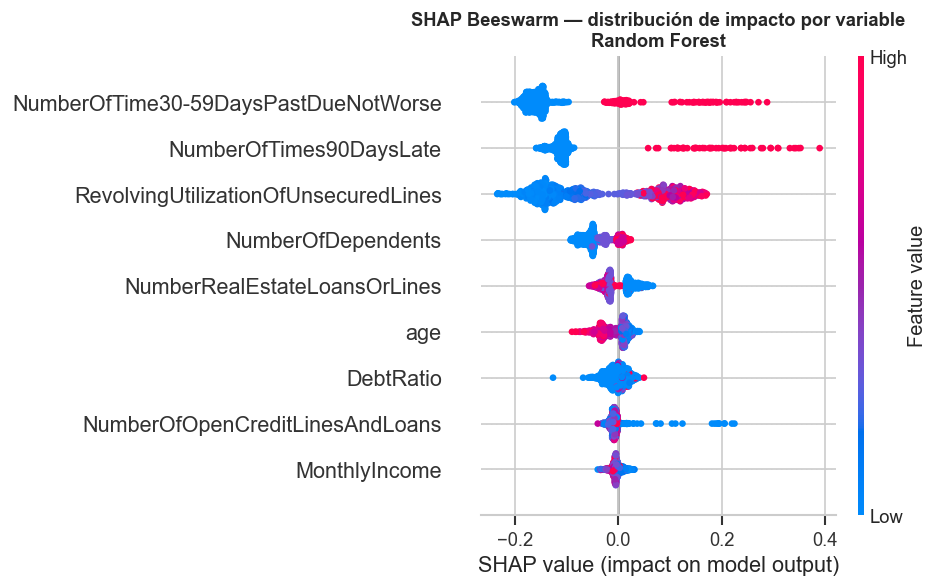

In [14]:
# Beeswarm plot — muestra distribución de impacto por feature
# Cada punto es un cliente, el color indica el valor de la variable
shap_explanation = shap.Explanation(
    values     = sv,
    base_values= explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
    data       = X_muestra.values,
    feature_names = FEATURES
)

plt.figure()
shap.plots.beeswarm(shap_explanation, max_display=10, show=False)
plt.title(f'SHAP Beeswarm — distribución de impacto por variable\n{MODELO_NOMBRE}', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

**Cómo leer el Beeswarm:**
- Cada fila es una variable, cada punto es un cliente
- **Color rojo** = valor alto de la variable · **Color azul** = valor bajo
- **Posición en el eje X** = impacto en la predicción (derecha = empuja hacia moroso)
- Ejemplo: si `NumberOfTimes90DaysLate` aparece con puntos rojos a la derecha → tener muchos atrasos de 90 días aumenta fuertemente la probabilidad de default

---
## 6. SHAP global — efectos de cada variable

Los **dependence plots** muestran cómo varía el impacto de una variable según su valor real. Revelan relaciones no lineales que los modelos capturan pero que una importancia simple no muestra.

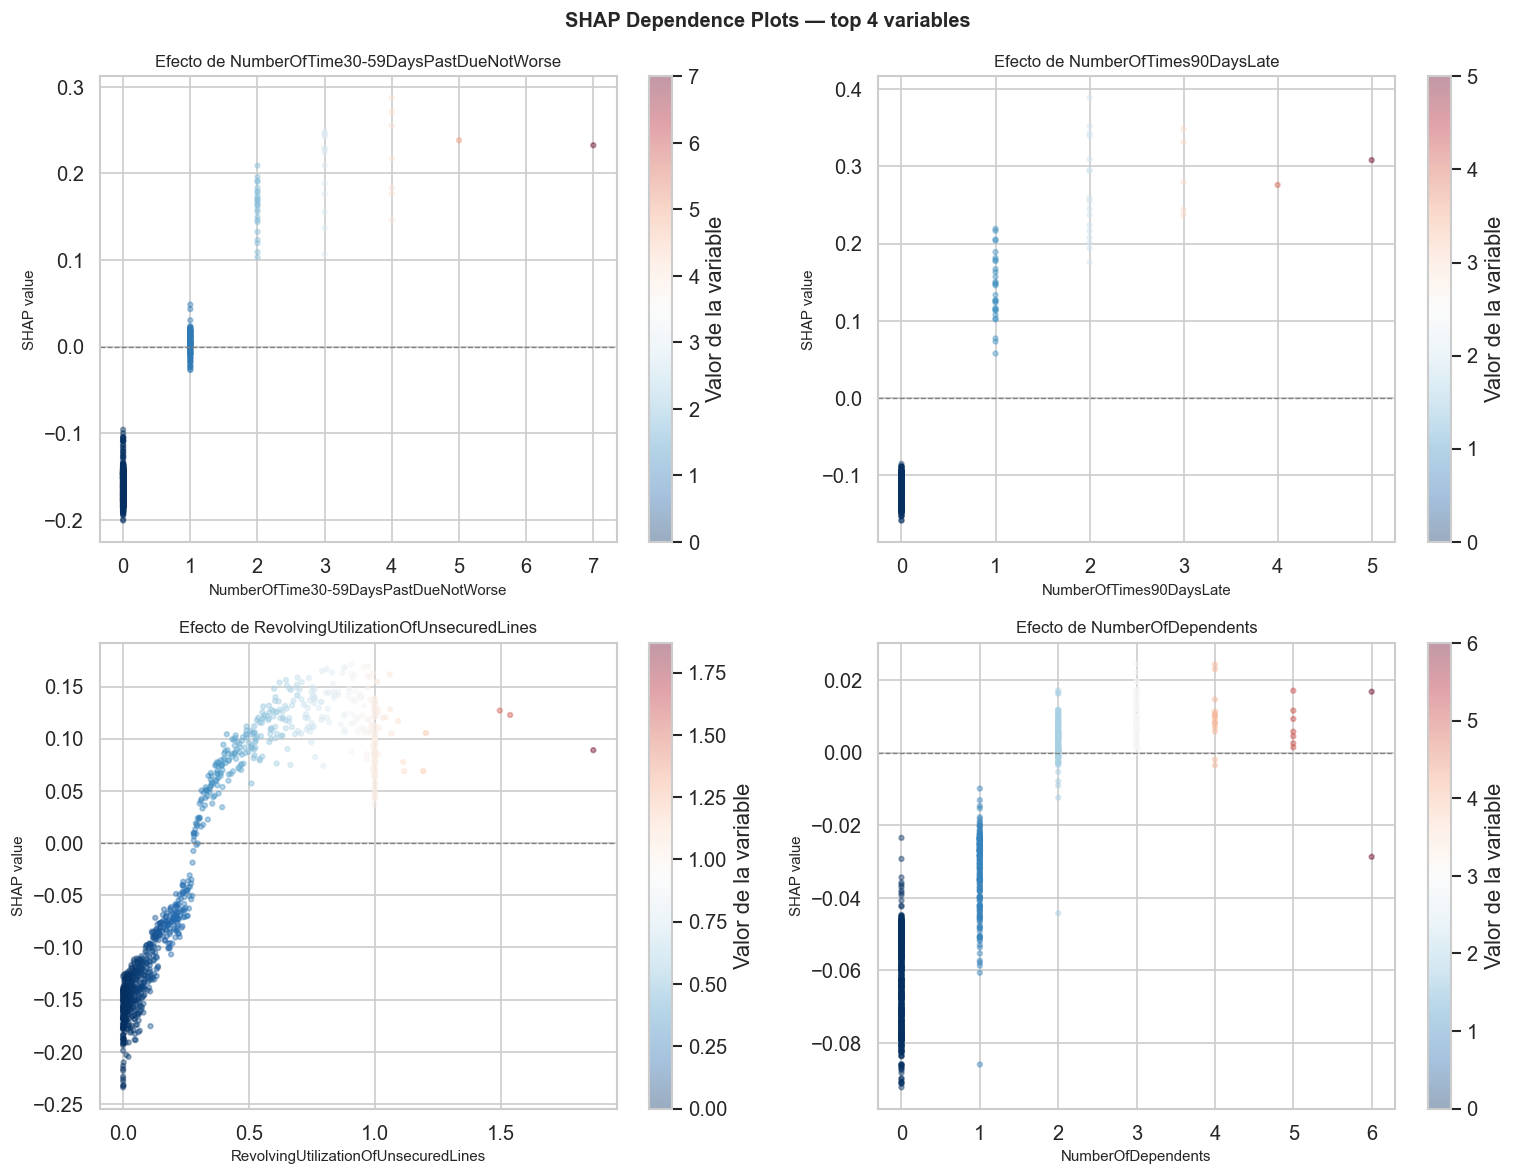

In [15]:
# Top 4 variables más importantes según SHAP
top4 = importancia_shap.sort_values('SHAP medio', ascending=False)['Feature'].head(4).tolist()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, feature in enumerate(top4):
    idx_feature = FEATURES.index(feature)
    valores_x   = X_muestra[feature].values
    valores_shap = sv[:, idx_feature]

    sc = axes[i].scatter(valores_x, valores_shap, c=valores_x, cmap='RdBu_r', alpha=0.4, s=8)
    axes[i].axhline(0, color='gray', lw=0.8, ls='--')
    axes[i].set_xlabel(feature, fontsize=9)
    axes[i].set_ylabel('SHAP value', fontsize=9)
    axes[i].set_title(f'Efecto de {feature}', fontsize=10)
    plt.colorbar(sc, ax=axes[i], label='Valor de la variable')

plt.suptitle('SHAP Dependence Plots — top 4 variables', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. SHAP local — explicación por cliente individual

El análisis local responde a la pregunta: **¿por qué el modelo clasificó a ESTE cliente como moroso?**

Esto es lo que alimentará la explicación en la app de Streamlit — cada predicción tendrá su propio desglose.

In [16]:
# Seleccionar un moroso real bien detectado (verdadero positivo)
# y un moroso no detectado (falso negativo) para comparar

probs_muestra = modelo.predict_proba(X_muestra)[:, 1]
preds_muestra = (probs_muestra >= UMBRAL).astype(int)
reales_muestra = y_test.iloc[idx_muestra].values

tp_idx = np.where((reales_muestra == 1) & (preds_muestra == 1))[0]
fn_idx = np.where((reales_muestra == 1) & (preds_muestra == 0))[0]

print(f'Verdaderos positivos en la muestra: {len(tp_idx)}')
print(f'Falsos negativos en la muestra    : {len(fn_idx)}')

Verdaderos positivos en la muestra: 42
Falsos negativos en la muestra    : 37


In [18]:
def explicar_cliente(idx, etiqueta):
    # Extraer base_value como escalar
    ev = explainer.expected_value
    if isinstance(ev, (list, np.ndarray)):
        base_value = float(ev[1])
    else:
        base_value = float(ev)

    exp = shap.Explanation(
        values        = sv[idx].astype(float),
        base_values   = base_value,
        data          = X_muestra.iloc[idx].values.astype(float),
        feature_names = FEATURES
    )

    prob_cliente = probs_muestra[idx]
    print(f'\n=== {etiqueta} ===')
    print(f'Probabilidad de default: {prob_cliente:.2%}')
    print(f'Clasificación: {"MOROSO" if preds_muestra[idx] == 1 else "NO MOROSO"}')
    print()

    contrib = pd.DataFrame({
        'Feature' : FEATURES,
        'Valor'   : X_muestra.iloc[idx].values,
        'SHAP'    : sv[idx]
    }).sort_values('SHAP', key=abs, ascending=False)
    print(contrib.to_string(index=False))

    plt.figure()
    shap.plots.waterfall(exp, show=False)
    plt.title(f'SHAP Waterfall — {etiqueta}\nP(default)={prob_cliente:.2%}',
            fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [20]:
def predecir_cliente_nuevo(datos_cliente: dict) -> dict:
    """
    Recibe un diccionario con los datos de un cliente nuevo,
    retorna la probabilidad de default y los valores SHAP.

    Ejemplo de uso:
        datos = {
            'RevolvingUtilizationOfUnsecuredLines': 0.75,
            'age': 35,
            'NumberOfTime30-59DaysPastDueNotWorse': 1,
            ...
        }
        resultado = predecir_cliente_nuevo(datos)
    """
    X_nuevo = pd.DataFrame([datos_cliente])[FEATURES]

    prob          = modelo.predict_proba(X_nuevo)[0, 1]
    clasificacion = 'MOROSO' if prob >= UMBRAL else 'NO MOROSO'

    shap_nuevo = explainer.shap_values(X_nuevo)

    # Manejo robusto de los 3 formatos posibles de TreeExplainer
    if isinstance(shap_nuevo, list):
        sv_nuevo = np.array(shap_nuevo[1][0], dtype=float)
    elif shap_nuevo.ndim == 3:
        sv_nuevo = shap_nuevo[0, :, 1].astype(float)
    else:
        sv_nuevo = shap_nuevo[0].astype(float)

    return {
        'probabilidad'  : round(float(prob), 4),
        'clasificacion' : clasificacion,
        'umbral'        : UMBRAL,
        'shap_values'   : dict(zip(FEATURES, sv_nuevo.tolist())),
    }


# Ejemplo de prueba
cliente_ejemplo = {
    'RevolvingUtilizationOfUnsecuredLines': 0.85,
    'age': 28,
    'NumberOfTime30-59DaysPastDueNotWorse': 2,
    'DebtRatio': 0.45,
    'MonthlyIncome': 3200,
    'NumberOfOpenCreditLinesAndLoans': 4,
    'NumberOfTimes90DaysLate': 1,
    'NumberRealEstateLoansOrLines': 0,
    'NumberOfTime60-89DaysPastDueNotWorse': 1,
    'NumberOfDependents': 2
}

resultado = predecir_cliente_nuevo(cliente_ejemplo)
print('=== Predicción para cliente de ejemplo ===')
print(f'Probabilidad de default : {resultado["probabilidad"]:.2%}')
print(f'Clasificación           : {resultado["clasificacion"]}')
print()
print('Contribución SHAP por variable:')
shap_df = pd.DataFrame(resultado['shap_values'].items(),
                    columns=['Feature', 'SHAP'])
shap_df['SHAP'] = shap_df['SHAP'].astype(float)
shap_df = shap_df.sort_values('SHAP', key=lambda x: x.abs(), ascending=False)
print(shap_df.to_string(index=False))

=== Predicción para cliente de ejemplo ===
Probabilidad de default : 80.95%
Clasificación           : MOROSO

Contribución SHAP por variable:
                             Feature     SHAP
NumberOfTime30-59DaysPastDueNotWorse 0.096426
             NumberOfTimes90DaysLate 0.082461
RevolvingUtilizationOfUnsecuredLines 0.076316
        NumberRealEstateLoansOrLines 0.024820
                           DebtRatio 0.013558
                                 age 0.007398
                       MonthlyIncome 0.003397
                  NumberOfDependents 0.003215
     NumberOfOpenCreditLinesAndLoans 0.002005


---
## 8. Conclusiones

### Resumen del modelo ganador

In [21]:
top3_shap = importancia_shap.sort_values('SHAP medio', ascending=False)['Feature'].head(3).tolist()

print('╔══════════════════════════════════════════════════════════╗')
print(f'  MODELO FINAL: {MODELO_NOMBRE}')
print(f'  Umbral óptimo : {UMBRAL}')
print(f'  AUC-ROC       : {auc:.4f}')
print(f'  Recall        : {recall:.4f}  ({recall:.1%} de morosos detectados)')
print(f'  F1-Score      : {f1:.4f}')
print()
print(f'  Morosos en test set    : {y_test.sum():,}')
print(f'  Morosos detectados     : {tp:,}')
print(f'  Morosos no detectados  : {fn:,}  ← objetivo: reducir')
print()
print(f'  Variables más influyentes (SHAP):')
for i, v in enumerate(top3_shap, 1):
    print(f'    {i}. {v}')
print('╚══════════════════════════════════════════════════════════╝')
print()
print('Siguiente paso: App Streamlit')

╔══════════════════════════════════════════════════════════╗
  MODELO FINAL: Random Forest
  Umbral óptimo : 0.49
  AUC-ROC       : 0.8513
  Recall        : 0.4539  (45.4% de morosos detectados)
  F1-Score      : 0.4090

  Morosos en test set    : 2,005
  Morosos detectados     : 910
  Morosos no detectados  : 1,095  ← objetivo: reducir

  Variables más influyentes (SHAP):
    1. NumberOfTime30-59DaysPastDueNotWorse
    2. NumberOfTimes90DaysLate
    3. RevolvingUtilizationOfUnsecuredLines
╚══════════════════════════════════════════════════════════╝

Siguiente paso: App Streamlit
